# (노트) Pytorch CNN (MNIST 3,7)

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [빅데이터분석]

### import 

In [1]:
import torch 
from fastai.vision.all import *

In [2]:
import graphviz

In [3]:
def gv(s): return graphviz.Source('digraph G{ rankdir="LR"' + s + '; }')

### data

`-` download data 

In [4]:
path = untar_data(URLs.MNIST_SAMPLE)

In [5]:
path.ls()

(#3) [Path('/home/cgb4/.fastai/data/mnist_sample/labels.csv'),Path('/home/cgb4/.fastai/data/mnist_sample/train'),Path('/home/cgb4/.fastai/data/mnist_sample/valid')]

`-` list

In [6]:
threes=(path/'train'/'3').ls()
sevens=(path/'train'/'7').ls()

`-` list $\to$ image 

In [7]:
Image.open(threes[0])

`-` image $\to$ tensor

In [8]:
tensor(Image.open(threes[0]))

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,  1

- tensor는 fastai에서 구현한 함수. 리턴값은 파이토치에서 우리가 쓰던 그 텐서

`-` 여러개를 처리하여보자. 

In [9]:
seven_tensor = torch.stack([tensor(Image.open(i)) for i in sevens]).float()/255
three_tensor = torch.stack([tensor(Image.open(i)) for i in threes]).float()/255

`-` $X$와 $y$를 만들자.

In [10]:
seven_tensor.shape, three_tensor.shape

(torch.Size([6265, 28, 28]), torch.Size([6131, 28, 28]))

In [11]:
y=torch.tensor([0.0]*6265 + [1.0]*6131).reshape(12396,1)

In [12]:
X=torch.vstack([seven_tensor,three_tensor])

In [13]:
X=X.reshape(12396,28*28)

In [14]:
X.shape

torch.Size([12396, 784])

In [15]:
y.shape

torch.Size([12396, 1])

### 모형 (기존모형)

`-` 교재의 모형

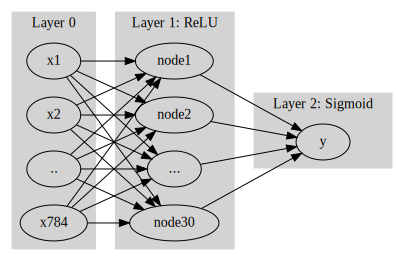

In [16]:
#collapse
gv('''
splines=line
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "x1"
    "x2"
    ".."
    "x784"
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "x1" -> "node1"
    "x2" -> "node1"
    ".." -> "node1"
    
    "x784" -> "node1"
    "x1" -> "node2"
    "x2" -> "node2"
    ".." -> "node2"
    "x784" -> "node2"
    
    "x1" -> "..."
    "x2" -> "..."
    ".." -> "..."
    "x784" -> "..."

    "x1" -> "node30"
    "x2" -> "node30"
    ".." -> "node30"
    "x784" -> "node30"


    label = "Layer 1: ReLU"
}
subgraph cluster_3{
    style=filled;
    color=lightgrey;
    "node1" -> "y"
    "node2" -> "y"
    "..." -> "y"
    "node30" -> "y"
    label = "Layer 2: Sigmoid"
}
''')

`-` 왜 28$\times$28 이미지를 784개의 벡터로 만든 다음에 모형을 돌려야 하는가? 

`-` 기존에 개발된 모형이 회귀분석기반으로 되어있어서 결국 회귀분석 틀에 짜맞춰서 이미지자료를 분석하고 있는 꼴

`-` observation의 차원은 $1\times 784$가 아니라 $1\times (28\times 28)$이 되어야 맞다. 

`-` 더 정확하게는 칼라이미지니까 $1\times (3 \times 28 \times 28)$ 이 되어야 맞음 

In [17]:
X.shape

torch.Size([12396, 784])

In [44]:
X=X.reshape(12396,1,28,28)

In [45]:
X.shape

torch.Size([12396, 1, 28, 28])

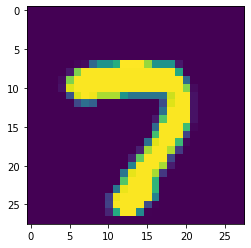

In [120]:
plt.imshow(X[776][0]) # 777 observation, first channel 

### 선형변환 대신에 2d convolution with windowsize=5

In [177]:
c1=torch.nn.Conv2d(1,16,5) #입력채널=1: 흑백이니까, 아웃풋채널=16

In [178]:
c1(X).shape

torch.Size([12396, 16, 24, 24])

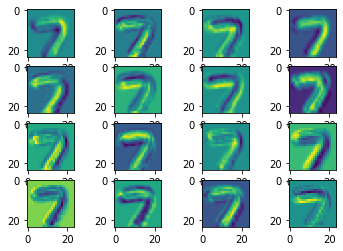

In [179]:
fig, axs = plt.subplots(4,4)
k=0
for i in range(4):
    for j in range(4):
        axs[i,j].imshow(c1(X)[776][k].data)
        k=k+1

In [180]:
fig.set_figheight(8)
fig.set_figwidth(8)
fig.tight_layout()

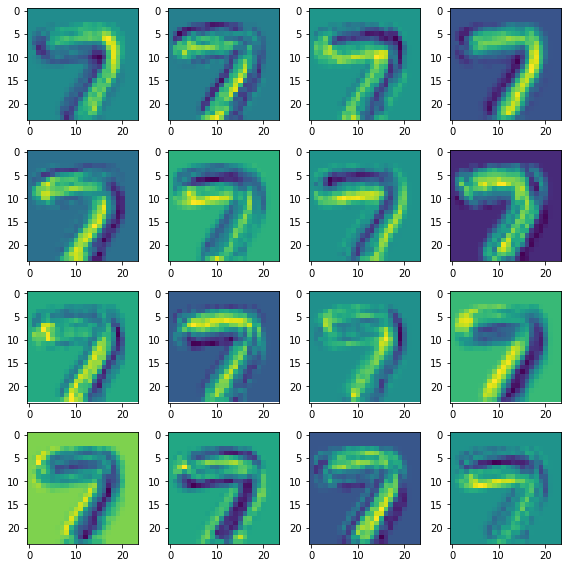

In [181]:
fig

### ReLU() 대신에 MaxPool2d + ReLU

### maxpooling 

In [182]:
m1=torch.nn.MaxPool2d(2)

In [183]:
c1(X).shape,m1(c1(X)).shape

(torch.Size([12396, 16, 24, 24]), torch.Size([12396, 16, 12, 12]))

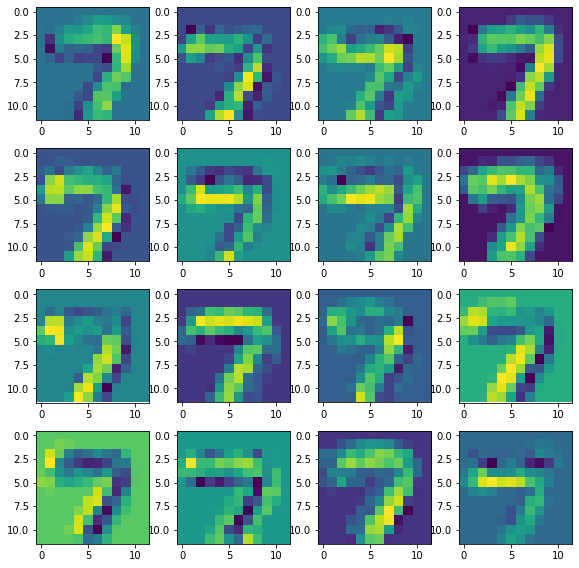

In [184]:
fig, axs = plt.subplots(4,4)
k=0
for i in range(4):
    for j in range(4):
        axs[i,j].imshow(m1(c1(X))[776][k].data)
        k=k+1
fig.set_figheight(8)
fig.set_figwidth(8)
fig.tight_layout()        

#### ReLU 

In [185]:
a1=nn.ReLU()

In [186]:
c1(X).shape,m1(c1(X)).shape,a1(m1(c1(X))).shape

(torch.Size([12396, 16, 24, 24]),
 torch.Size([12396, 16, 12, 12]),
 torch.Size([12396, 16, 12, 12]))

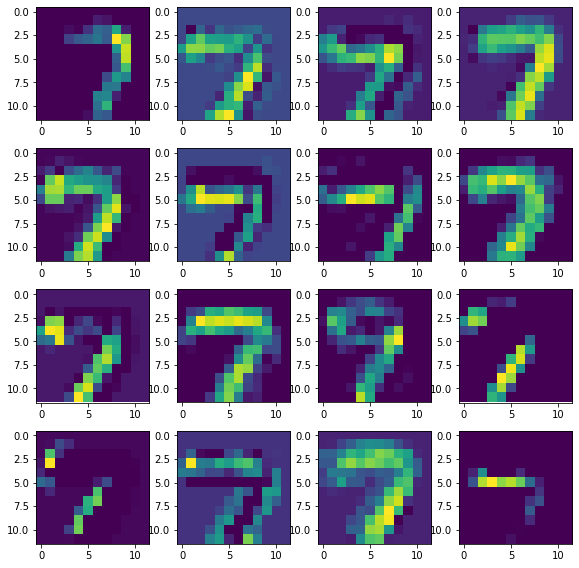

In [187]:
fig, axs = plt.subplots(4,4)
k=0
for i in range(4):
    for j in range(4):
        axs[i,j].imshow(a1(m1(c1(X)))[776][k].data)
        k=k+1
fig.set_figheight(8)
fig.set_figwidth(8)
fig.tight_layout()        

In [188]:
torch.manual_seed(1)
_A=torch.randn(3,3)
_A

tensor([[ 0.6614,  0.2669,  0.0617],
        [ 0.6213, -0.4519, -0.1661],
        [-1.5228,  0.3817, -1.0276]])

In [189]:
a1(_A)

tensor([[0.6614, 0.2669, 0.0617],
        [0.6213, 0.0000, 0.0000],
        [0.0000, 0.3817, 0.0000]])

### 이제 그냥 시그모이드에 태우자!!

`-` 현재상황

In [192]:
a1(m1(c1(X))).shape

torch.Size([12396, 16, 12, 12])

`-` 펼치자 

In [215]:
a1(m1(c1(X))).reshape(12396,-1).shape

torch.Size([12396, 2304])

`-` 일단 2304 저 디멘젼을 1로 만들어야겠음 

In [216]:
l1=torch.nn.Linear(in_features=2304, out_features=1) 
l1(a1(m1(c1(X))).reshape(12396,-1))

tensor([[-0.1109],
        [-0.0927],
        [ 0.0588],
        ...,
        [-0.0183],
        [-0.0092],
        [ 0.0097]], grad_fn=<AddmmBackward>)

`-` 시그모이드를 태우자. 

In [217]:
a2=torch.nn.Sigmoid() 
a2(l1(a1(m1(c1(X))).reshape(12396,-1)))

tensor([[0.4723],
        [0.4768],
        [0.5147],
        ...,
        [0.4954],
        [0.4977],
        [0.5024]], grad_fn=<SigmoidBackward>)

### networks 설계 

In [311]:
net=torch.nn.Sequential(
    c1, # 컨볼루션 (선형)
    m1, # 맥스풀링 (비선형) -- 효과? 나중에 다룰것: 이미지를 계층적으로 파악함
    a1, # 렐루 (비선형) 
    
    
    a1(m1(c1(X))).reshape(12396,-1), ## 이걸어떻게구현하지? 
    
    
    l1) # 선형변환 
## 마지막의 a2는 생략한다. 손실함수에 이미 내장되어 있으므로 

TypeError: torch.FloatTensor is not a Module subclass

In [312]:
net=torch.nn.Sequential(
    c1, # 컨볼루션 (선형)
    m1, # 맥스풀링 (비선형) -- 효과? 나중에 다룰것: 이미지를 계층적으로 파악함
    a1, # 렐루 (비선형) 
    
    
#    a1(m1(c1(X))).reshape(12396,-1), ## 이걸어떻게구현하지? 
    
    
    l1) # 선형변환 
## 마지막의 a2는 생략한다. 손실함수에 이미 내장되어 있으므로.

결국 주석처리한 부분을 구현해야함. 


`-` `c1`, `m1` ,`a1` ,`l1` 의 공통점? 
- 무언가를 상속받는 클래스에서 생성된 인스턴스이다. 
- forward 메소드가 있다. 

`-` `c1`, `m1` ,`a1` ,`l1` 과 같은 레이어를 만드는 방법? (custom layer를 만드는 방법) 
- torch.nn.Module을 상속받아서 클래스를 하나 만든다. 
- forward 메소드를 정의한다. (다음층으로 리턴할 값)

In [239]:
class Flatten(torch.nn.Module):
    def forward(self,x): 
        return x.reshape(12396,-1) 

In [240]:
flatten=Flatten()

In [242]:
a1(m1(c1(X))).shape

torch.Size([12396, 16, 12, 12])

In [243]:
flatten(a1(m1(c1(X)))).shape

torch.Size([12396, 2304])

`-` 잘구현된것 같다! 이제 다시 네트워크를 만들자. 

In [313]:
net=torch.nn.Sequential(
    c1, # 컨볼루션 (선형)
    m1, # 맥스풀링 (비선형) -- 효과? 나중에 다룰것: 이미지를 계층적으로 파악함
    a1, # 렐루 (비선형) 
    flatten, # a1(m1(c1(X))).reshape(12396,-1), ## 이걸어떻게구현하지? 
    l1) # 선형변환 
## 마지막의 a2는 생략한다. 손실함수에 이미 내장되어 있으므로 

`-` 손실함수와 옵티마이저 정의 

In [314]:
loss_fn=torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(net.parameters())

`-` step 1~4 

In [315]:
for epoc in range(200): 
    ## 1 
    yhat=net(X)
    ## 2 
    loss= loss_fn(yhat,y)
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step() 
    net.zero_grad()

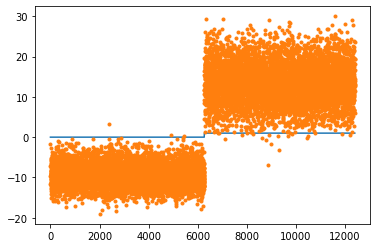

In [316]:
plt.plot(y)
plt.plot(yhat.data,'.')

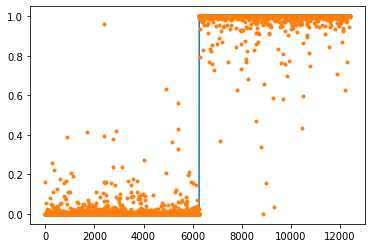

In [317]:
plt.plot(y)
plt.plot(a2(yhat.data),'.')

In [318]:
ypred= a2(yhat.data)>0.5

In [319]:
sum(ypred==y)/12396

tensor([0.9992])

`-` 좀 더 좋아졌다.. (이미 좋았는데 더 좋아짐) 

### fastai (더 쉽게 하고 싶어요) 

#### step1: dls를 만들자

In [320]:
(path/'train').ls()

(#2) [Path('/home/cgb4/.fastai/data/mnist_sample/train/3'),Path('/home/cgb4/.fastai/data/mnist_sample/train/7')]

In [321]:
dls1 = ImageDataLoaders.from_folder(
    path,
    train='train',
    valid_pct=0.2)       

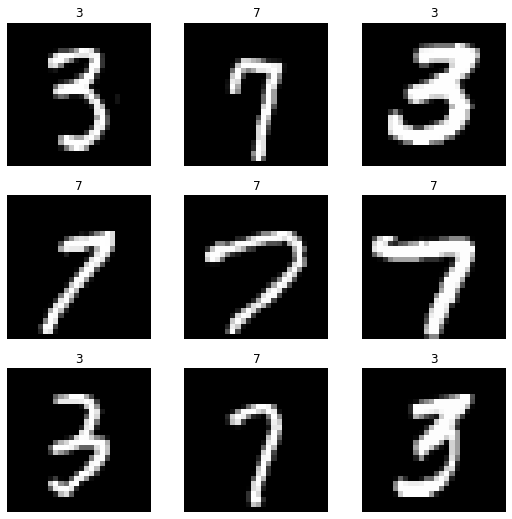

In [322]:
dls1.show_batch()

#### step2: 아키텍처, 손실함수, 옵티마이저

`-` 네트워크 수정 

In [362]:
class Flatten(torch.nn.Module):
    def forward(self,x): 
        return x.reshape(x.shape[0],-1) 

In [363]:
flatten=Flatten()

In [364]:
net=torch.nn.Sequential(
    torch.nn.Conv2d(3,16,5), # 
    m1, # 맥스풀링 (비선형) -- 효과? 나중에 다룰것: 이미지를 계층적으로 파악함
    a1, # 렐루 (비선형) 
    flatten, # a1(m1(c1(X))).reshape(12396,-1), ## 이걸어떻게구현하지? 
    l1) # 선형변환 
## 마지막의 a2는 생략한다. 손실함수에 이미 내장되어 있으므로 

#### step3: lrnr 생성 

In [373]:
lrnr1=Learner(dls1,net,opt_func=Adam,loss_func=loss_fn)

In [374]:
lrnr1.fit(1)

epoch,train_loss,valid_loss,time


ValueError: Target size (torch.Size([64])) must be the same as input size (torch.Size([64, 1]))

### 각층에서 무슨일이 일어난것인가? 

`-` 선형변환 

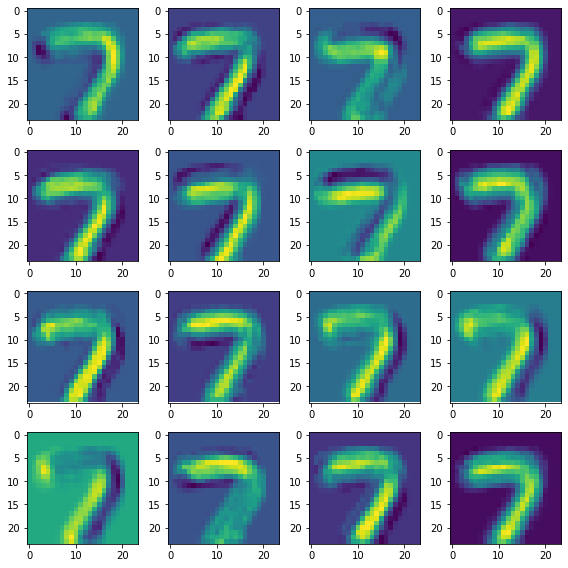

In [251]:
fig, axs = plt.subplots(4,4)
k=0
for i in range(4):
    for j in range(4):
        axs[i,j].imshow(c1(X)[776][k].data)
        k=k+1
fig.set_figheight(8)
fig.set_figwidth(8)
fig.tight_layout()

일부 특징이 강화되어있음 

`-` 맥스풀링 

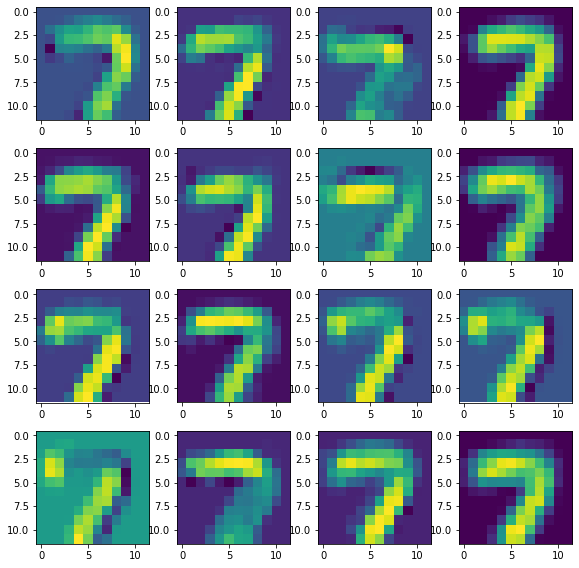

In [252]:
fig, axs = plt.subplots(4,4)
k=0
for i in range(4):
    for j in range(4):
        axs[i,j].imshow(m1(c1(X))[776][k].data)
        k=k+1
fig.set_figheight(8)
fig.set_figwidth(8)
fig.tight_layout()

`-` 렐루

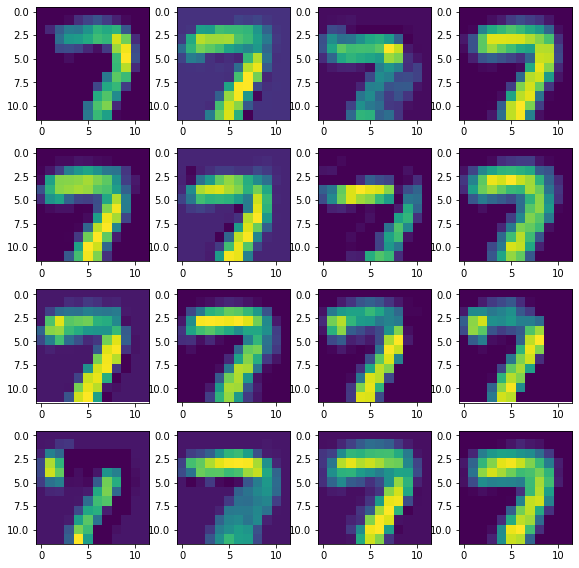

In [268]:
fig, axs = plt.subplots(4,4)
k=0
for i in range(4):
    for j in range(4):
        axs[i,j].imshow(a1(m1(c1(X)))[776][k].data)
        k=k+1
fig.set_figheight(8)
fig.set_figwidth(8)
fig.tight_layout()